In [2]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

df=pd.read_csv("/content/final_dataset.csv")


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

first 5 rows

In [3]:
df.head()

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm


to lowercase

In [5]:



df['lowercase_text'] = df['text'].str.lower()
df['lowercase_emotion'] = df['emotion'].str.lower()


print(df[['text', 'lowercase_text', 'emotion', 'lowercase_emotion']].head())

                                                text  \
0  i feel rather funny ending with so many dupes ...   
1                     i feel surprised by the result   
2                    i am officially feeling festive   
3  i suddenly found myself standing before this w...   
4  i look at the meager pile of food i purchased ...   

                                      lowercase_text     emotion  \
0  i feel rather funny ending with so many dupes ...         fun   
1                     i feel surprised by the result    surprise   
2                    i am officially feeling festive     neutral   
3  i suddenly found myself standing before this w...    surprise   
4  i look at the meager pile of food i purchased ...  enthusiasm   

  lowercase_emotion  
0               fun  
1          surprise  
2           neutral  
3          surprise  
4        enthusiasm  


tokenization

In [6]:
df['tokens'] = df['text'].apply(lambda x: x.split())


print(df[['text', 'tokens']].head())

                                                text  \
0  i feel rather funny ending with so many dupes ...   
1                     i feel surprised by the result   
2                    i am officially feeling festive   
3  i suddenly found myself standing before this w...   
4  i look at the meager pile of food i purchased ...   

                                              tokens  
0  [i, feel, rather, funny, ending, with, so, man...  
1              [i, feel, surprised, by, the, result]  
2              [i, am, officially, feeling, festive]  
3  [i, suddenly, found, myself, standing, before,...  
4  [i, look, at, the, meager, pile, of, food, i, ...  


Stopword Removal

In [7]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)


df['text_without_stopwords'] = df['text'].apply(remove_stopwords)

print(df[['text', 'text_without_stopwords']].head())


                                                text  \
0  i feel rather funny ending with so many dupes ...   
1                     i feel surprised by the result   
2                    i am officially feeling festive   
3  i suddenly found myself standing before this w...   
4  i look at the meager pile of food i purchased ...   

                              text_without_stopwords  
0  feel rather funny ending many dupes always pre...  
1                              feel surprised result  
2                         officially feeling festive  
3  suddenly found standing woman dressed like pri...  
4  look meager pile food purchased week feeling p...  


Stemming

In [9]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()


def stem_text(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)


df['stemmed_text'] = df['text'].apply(stem_text)


print(df[['text', 'stemmed_text']].head(10))

                                                text  \
0  i feel rather funny ending with so many dupes ...   
1                     i feel surprised by the result   
2                    i am officially feeling festive   
3  i suddenly found myself standing before this w...   
4  i look at the meager pile of food i purchased ...   
5  i, for one, am thrilled that christ works outs...   
6  i hate that she has the power to make me feel ...   
7                            i feel like i missed it   
8  i have personally experienced this gut wrenchi...   
9  i hate feeling that people see me as ugly but ...   

                                        stemmed_text  
0  i feel rather funni end with so mani dupe whil...  
1                       i feel surpris by the result  
2                            i am offici feel festiv  
3  i suddenli found myself stand befor thi woman ...  
4  i look at the meager pile of food i purchas fo...  
5  i, for one, am thrill that christ work outsid ... 

 Lemmatization

In [10]:

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


def stem_text(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)


def lemmatize_text(text):
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)


df['stemmed_text'] = df['text'].apply(stem_text)
df['lemmatized_text'] = df['text'].apply(lemmatize_text)


print(df[['text', 'stemmed_text', 'lemmatized_text']].head(10))



                                                text  \
0  i feel rather funny ending with so many dupes ...   
1                     i feel surprised by the result   
2                    i am officially feeling festive   
3  i suddenly found myself standing before this w...   
4  i look at the meager pile of food i purchased ...   
5  i, for one, am thrilled that christ works outs...   
6  i hate that she has the power to make me feel ...   
7                            i feel like i missed it   
8  i have personally experienced this gut wrenchi...   
9  i hate feeling that people see me as ugly but ...   

                                        stemmed_text  \
0  i feel rather funni end with so mani dupe whil...   
1                       i feel surpris by the result   
2                            i am offici feel festiv   
3  i suddenli found myself stand befor thi woman ...   
4  i look at the meager pile of food i purchas fo...   
5  i, for one, am thrill that christ work outsi

Bag of Words (BoW)

In [12]:
from sklearn.feature_extraction.text import CountVectorizer


text_data = df['text']

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(text_data)

print("Vocabulary:\n")
print(vectorizer.vocabulary_)

print("\nFeature Names:\n")
print(vectorizer.get_feature_names_out())

print("\nBag of Words Matrix:\n")
print(X.toarray())

print("\nShape of Matrix:")
print(X.shape)


Vocabulary:

{'feel': 13807, 'rather': 31096, 'funny': 15178, 'ending': 12414, 'with': 42802, 'so': 35471, 'many': 23501, 'dupes': 11654, 'while': 42472, 'always': 1684, 'prefer': 29812, 'originals': 27377, 'surprised': 37438, 'by': 5711, 'the': 38469, 'result': 32134, 'am': 1697, 'officially': 26905, 'feeling': 13820, 'festive': 13923, 'suddenly': 37130, 'found': 14738, 'myself': 25566, 'standing': 36355, 'before': 3784, 'this': 38632, 'woman': 42900, 'dressed': 11427, 'like': 22330, 'priestess': 29993, 'white': 42516, 'robes': 32553, 'and': 1884, 'egyptian': 12041, 'jewellery': 20368, 'long': 22714, 'black': 4329, 'hair': 16919, 'realized': 31225, 'that': 38449, 'was': 42064, 'amorous': 1807, 'passionate': 28163, 'noticed': 26495, 'to': 39043, 'my': 25541, 'surprise': 37437, 'breath': 5118, 'green': 16460, 'breathing': 5123, 'out': 27484, 'clouds': 7370, 'of': 26872, 'energy': 12452, 'look': 22745, 'at': 2726, 'meager': 23920, 'pile': 28922, 'food': 14553, 'purchased': 30551, 'for': 

 TF-IDF Vectorization

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

text_data = df['text']

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(text_data)

print("Vocabulary:\n")
print(vectorizer.vocabulary_)

print("\nTF-IDF Matrix:\n")
print(X.toarray())

print("\nShape of Matrix:")
print(X.shape)


Vocabulary:

{'feel': 13807, 'rather': 31096, 'funny': 15178, 'ending': 12414, 'with': 42802, 'so': 35471, 'many': 23501, 'dupes': 11654, 'while': 42472, 'always': 1684, 'prefer': 29812, 'originals': 27377, 'surprised': 37438, 'by': 5711, 'the': 38469, 'result': 32134, 'am': 1697, 'officially': 26905, 'feeling': 13820, 'festive': 13923, 'suddenly': 37130, 'found': 14738, 'myself': 25566, 'standing': 36355, 'before': 3784, 'this': 38632, 'woman': 42900, 'dressed': 11427, 'like': 22330, 'priestess': 29993, 'white': 42516, 'robes': 32553, 'and': 1884, 'egyptian': 12041, 'jewellery': 20368, 'long': 22714, 'black': 4329, 'hair': 16919, 'realized': 31225, 'that': 38449, 'was': 42064, 'amorous': 1807, 'passionate': 28163, 'noticed': 26495, 'to': 39043, 'my': 25541, 'surprise': 37437, 'breath': 5118, 'green': 16460, 'breathing': 5123, 'out': 27484, 'clouds': 7370, 'of': 26872, 'energy': 12452, 'look': 22745, 'at': 2726, 'meager': 23920, 'pile': 28922, 'food': 14553, 'purchased': 30551, 'for': 

 Word Cloud

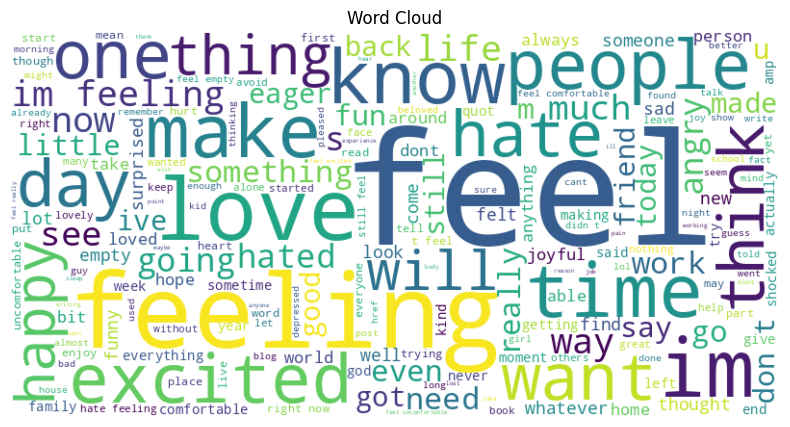

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud


text = ' '.join(df['text'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()
